# Setup
In this section, we will install and set our paths to our dataset. We first install the libraries. Each library is mentioned with its specified reason:
- `os` - to 
- `matplotlib` - to display the images before processing, after processing

In [30]:
import os
from skimage.metrics import structural_similarity as ssim
from collections import Counter
from pathlib import Path
import pickle
from PIL import Image
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
from copy import deepcopy
from itertools import product
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

from tqdm import tqdm
warnings.filterwarnings('ignore')

After this, we will set our paths accordingly to point to the train, valid and test folders.

In [2]:
dataset_path = Path('C:\\Users\Gracie\Downloads\Machine Learning\dataset')
training_data_path = dataset_path / 'train'
validation_data_path = dataset_path / 'valid'
testing_data_path = dataset_path / 'test'

# Verify the paths
print(f"Dataset path exists: {dataset_path.exists()}")
print(f"Training path exists: {training_data_path.exists()}")
print(f"Validation path exists: {validation_data_path.exists()}")
print(f"Testing path exists: {testing_data_path.exists()}")

Dataset path exists: True
Training path exists: True
Validation path exists: True
Testing path exists: True


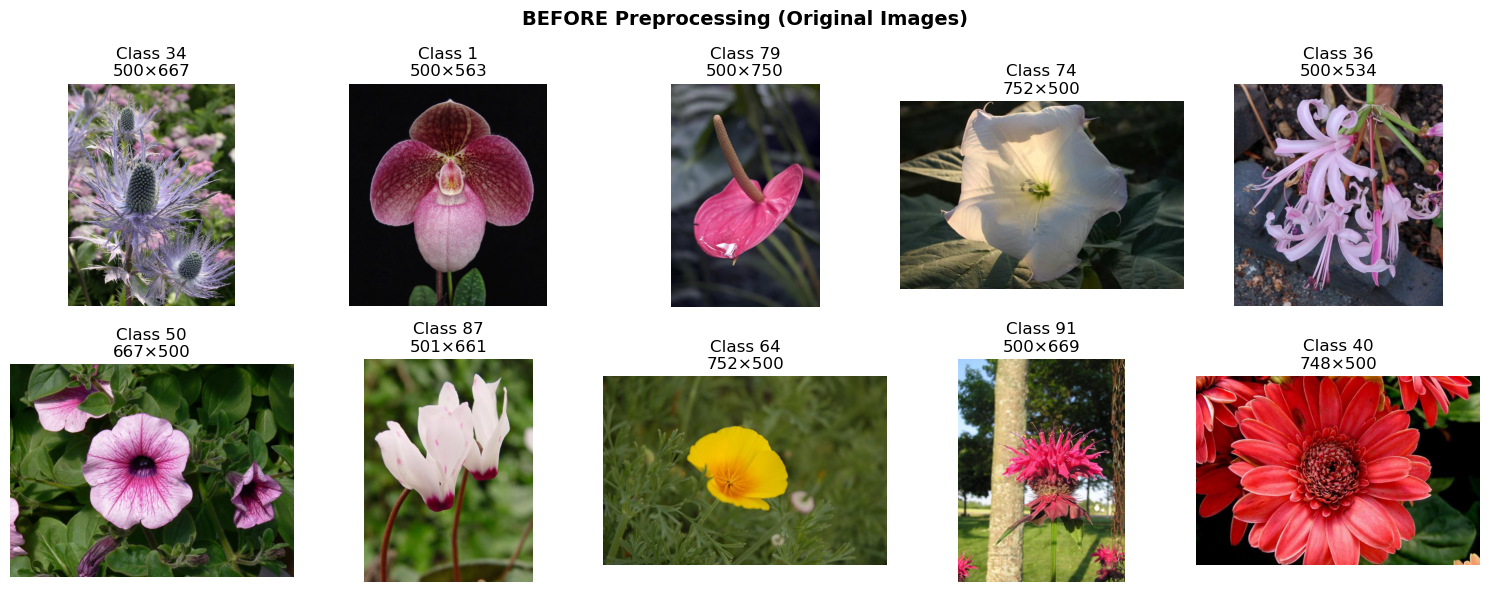

Original image properties:
  - Various sizes (not standardized)
  - RGB format (3 channels)
  - Pixel values: 0-255


In [3]:
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
axes = axes.flatten()

# Get 10 random images from training set (original, unprocessed)
np.random.seed(10)
all_image_paths = []
all_labels = []

for label, folder in enumerate(sorted(training_data_path.iterdir(), key=lambda x: int(x.name))):
    if folder.is_dir():
        for img_path in folder.glob('*.jpg'):
            all_image_paths.append(img_path)
            all_labels.append(label)

random_indices = np.random.choice(len(all_image_paths), 10, replace=False)

for idx, ax in enumerate(axes):
    img_idx = random_indices[idx]
    img = Image.open(all_image_paths[img_idx])
    ax.imshow(img)
    ax.set_title(f"Class {all_labels[img_idx]}\n{img.size[0]}×{img.size[1]}")
    ax.axis('off')

plt.suptitle("BEFORE Preprocessing (Original Images)", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("Original image properties:")
print("  - Various sizes (not standardized)")
print("  - RGB format (3 channels)")
print("  - Pixel values: 0-255")

# Verification Step
After installing and setting up the folder paths, we will need to inspect and understand our dataset. From there, we will need to process our data to see if there's any issues with it such as defected or corrupted images.

## Count number of images
In our given dataset, it is split across 3 different folders. We have our training set, validation set and our test set. Our training set and validation set contains several folders. These folders are our classes, representing our type of plants.

In [6]:
def count_images_per_class(data_dir):
    """Count the number of images in each class folder."""
    class_counts = {}
    for class_folder in sorted(os.listdir(data_dir)):
        class_path = os.path.join(data_dir, class_folder)
        if os.path.isdir(class_path):
            num_images = len([f for f in os.listdir(class_path)
                            if f.lower().endswith(('.png', '.jpg', '.jpeg'))])
            class_counts[class_folder] = num_images
    return class_counts

def count_images_flat(data_dir):
    return len([
        f for f in os.listdir(data_dir)
        if f.lower().endswith(('.png', '.jpg', '.jpeg'))
    ])

In [7]:
# Count images in each split
# For the test set, we will use the count from check_corrupted_images if it doesn't have class subfolders.
# The test_counts will be 0 if there are no subdirectories.
train_counts = count_images_per_class(training_data_path)
valid_counts = count_images_per_class(validation_data_path)
test_counts = count_images_per_class(testing_data_path)
test_image_count = count_images_flat(testing_data_path)

print(f"Training set: {sum(train_counts.values())} images across {len(train_counts)} classes")
print(f"Validation set: {sum(valid_counts.values())} images across {len(valid_counts)} classes")
print(f"Test set: {test_image_count} images (no class subfolders)")


Training set: 6552 images across 102 classes
Validation set: 818 images across 102 classes
Test set: 819 images (no class subfolders)


## Check for corrupted images
It's possible for our dataset to include corrupt or defected images. We need to verify if this is or isn't the case.

In [8]:
def check_corrupted_images(folder_path):
    """
    Scan all images in a folder and check if they can be opened.
    Returns lists of valid and corrupted image paths.
    """
    valid_images = []
    corrupted_images = []

    # Walk through all subfolders (class folders)
    for root, directories, files in os.walk(folder_path):
        for filename in files:
            if filename.lower().endswith(('.jpg', '.jpeg', '.png')):
                img_path = os.path.join(root, filename)
                try:
                    # Try to open and verify the image
                    with Image.open(img_path) as img:
                        img.verify()  # This checks if file is corrupted
                    valid_images.append(img_path)
                except Exception as e:
                    corrupted_images.append((img_path, str(e)))

    return valid_images, corrupted_images

In [9]:
# Run on each split
print("Checking TRAIN folder...")
train_valid, train_corrupted = check_corrupted_images(training_data_path)
print(f"  Valid: {len(train_valid)}, Corrupted: {len(train_corrupted)}")

print("Checking VALID folder...")
valid_valid, valid_corrupted = check_corrupted_images(validation_data_path)
print(f"  Valid: {len(valid_valid)}, Corrupted: {len(valid_corrupted)}")

print("Checking TEST folder...")
test_valid, test_corrupted = check_corrupted_images(testing_data_path)
print(f"  Valid: {len(test_valid)}, Corrupted: {len(test_corrupted)}")

# Show corrupted files if any
if train_corrupted:
    print("\n⚠️ Corrupted files in TRAIN:")
    for path, error in train_corrupted:
        print(f"  {path}: {error}")

Checking TRAIN folder...
  Valid: 6552, Corrupted: 0
Checking VALID folder...
  Valid: 818, Corrupted: 0
Checking TEST folder...
  Valid: 819, Corrupted: 0


In [10]:
def check_flipped_images(folder_path):
    """
    Scans images for EXIF orientation tags which indicate the image 
    might be rotated or flipped.
    """
    flipped_count = 0
    total_images = 0
    affected_files = []

    for root, dirs, files in os.walk(folder_path):
        for filename in files:
            if filename.lower().endswith(('.jpg', '.jpeg', '.png')):
                total_images += 1
                img_path = os.path.join(root, filename)
                try:
                    with Image.open(img_path) as img:
                        # EXIF tag 274 is 'Orientation'
                        exif = img._getexif()
                        if exif and 274 in exif:
                            orientation = exif[274]
                            # Orientations 2-8 imply some form of flipping or rotation
                            if orientation > 1:
                                flipped_count += 1
                                affected_files.append(img_path)
                except (AttributeError, KeyError, IndexError):
                    # No EXIF data found, assuming image is standard
                    pass
                except Exception as e:
                    print(f"Error checking {img_path}: {e}")

    print(f"Folder: {folder_path}")
    print(f"  - Total images scanned: {total_images}")
    print(f"  - Flipped/Rotated images detected: {flipped_count}")
    return affected_files

# Run the check on all paths
print("Checking for orientation issues...")
train_flipped = check_flipped_images(training_data_path)
valid_flipped = check_flipped_images(validation_data_path)
test_flipped = check_flipped_images(testing_data_path)

Checking for orientation issues...
Folder: C:\Users\Gracie\Downloads\Machine Learning\dataset\train
  - Total images scanned: 6552
  - Flipped/Rotated images detected: 0
Folder: C:\Users\Gracie\Downloads\Machine Learning\dataset\valid
  - Total images scanned: 818
  - Flipped/Rotated images detected: 0
Folder: C:\Users\Gracie\Downloads\Machine Learning\dataset\test
  - Total images scanned: 819
  - Flipped/Rotated images detected: 0


## Get image statistics

In [11]:
def get_image_stats(folder_path):
    """
    Collect dimension and file size statistics for all images.
    """
    dimensions = []
    file_sizes = []

    for root, dirs, files in os.walk(folder_path):
        for filename in files:
            if filename.lower().endswith(('.jpg', '.jpeg', '.png')):
                img_path = os.path.join(root, filename)
                try:
                    with Image.open(img_path) as img:
                        dimensions.append(img.size)  # (width, height)
                    file_sizes.append(os.path.getsize(img_path))
                except:
                    pass

    return dimensions, file_sizes

In [12]:
# Get stats for training set
dimensions, file_sizes = get_image_stats(training_data_path)

widths = [d[0] for d in dimensions]
heights = [d[1] for d in dimensions]

print("=" * 50)
print("IMAGE DIMENSION STATISTICS (Training Set)")
print("=" * 50)
print(f"Total images: {len(dimensions)}")
print(f"\nWidth:")
print(f"  Min: {min(widths)} px")
print(f"  Max: {max(widths)} px")
print(f"  Mean: {np.mean(widths):.1f} px")
print(f"\nHeight:")
print(f"  Min: {min(heights)} px")
print(f"  Max: {max(heights)} px")
print(f"  Mean: {np.mean(heights):.1f} px")
print(f"\nFile size:")
print(f"  Min: {min(file_sizes)/1024:.1f} KB")
print(f"  Max: {max(file_sizes)/1024:.1f} KB")
print(f"  Mean: {np.mean(file_sizes)/1024:.1f} KB")

IMAGE DIMENSION STATISTICS (Training Set)
Total images: 6552

Width:
  Min: 500 px
  Max: 1024 px
  Mean: 630.4 px

Height:
  Min: 500 px
  Max: 1168 px
  Mean: 534.3 px

File size:
  Min: 11.7 KB
  Max: 121.7 KB
  Mean: 41.3 KB


## Identify the distribution
We need to understand if our dataset is enough for each class. We expect the classes to be within a close range of numbers

In [13]:
def get_class_distribution(folder_path):
    """
    Count how many images are in each class folder.
    """
    class_counts = {}

    # Each subfolder is a class (named 1, 2, 3, ... 102)
    for class_folder in sorted(Path(folder_path).iterdir()):
        if class_folder.is_dir():
            class_name = class_folder.name
            # Count images in this class
            num_images = len(list(class_folder.glob("*.jpg"))) + \
                        len(list(class_folder.glob("*.png")))
            class_counts[class_name] = num_images
            
    return class_counts

In [14]:
# Get distribution
train_distribution = get_class_distribution(training_data_path)

# Convert to sorted list for analysis
class_names = sorted(train_distribution.keys(), key=lambda x: int(x))
counts = [train_distribution[c] for c in class_names]

print("=" * 50)
print("CLASS DISTRIBUTION (Training Set)")
print("=" * 50)
print(f"Number of classes: {len(train_distribution)}")
print(f"Total images: {sum(counts)}")
print(f"\nImages per class:")
print(f"  Min: {min(counts)} (Class {class_names[counts.index(min(counts))]})")
print(f"  Max: {max(counts)} (Class {class_names[counts.index(max(counts))]})")
print(f"  Mean: {np.mean(counts):.1f}")
print(f"  Std Dev: {np.std(counts):.1f}")

# Find underrepresented classes (less than mean - 1 std)
threshold = np.mean(counts) - np.std(counts)
underrepresented = [(c, train_distribution[c]) for c in class_names
                    if train_distribution[c] < threshold]

if underrepresented:
    print(f"\n⚠️ Underrepresented classes (< {threshold:.0f} images):")
    for cls, count in sorted(underrepresented, key=lambda x: x[1])[:10]:
        print(f"  Class {cls}: {count} images")

CLASS DISTRIBUTION (Training Set)
Number of classes: 102
Total images: 6552

Images per class:
  Min: 27 (Class 1)
  Max: 206 (Class 51)
  Mean: 64.2
  Std Dev: 35.2

⚠️ Underrepresented classes (< 29 images):
  Class 1: 27 images
  Class 34: 28 images


## Standardise image colour coding and normalise pixel values

In [15]:
from collections import Counter

def check_for_grayscale_and_color_modes(folder_path, dataset_name="Dataset"):
    """
    Checks for RGB, Grayscale ('L'), and other color modes.
    Reports explicitly if grayscale images are found.
    """
    mode_counts = Counter()
    total_images = 0
    grayscale_paths = []
    
    # Mapping codes to human-readable names
    mode_names = {
        'RGB': 'Standard Color (RGB)',
        'L': 'Grayscale (1-channel)',
        'RGBA': 'Color with Transparency (RGBA)',
        'P': 'Palette-based Color',
        '1': 'Black & White (Binary)',
        'CMYK': 'Print Color (CMYK)'
    }

    print(f"Scanning {dataset_name} for color consistency...")
    
    for root, _, files in os.walk(folder_path):
        for filename in files:
            if filename.lower().endswith(('.jpg', '.jpeg', '.png')):
                total_images += 1
                img_path = os.path.join(root, filename)
                try:
                    with Image.open(img_path) as img:
                        m = img.mode
                        mode_counts[m] += 1
                        # Capture paths for manual review if they are grayscale
                        if m == 'L' or m == '1':
                            grayscale_paths.append(img_path)
                except Exception as e:
                    print(f"Error: {img_path} - {e}")

    # Final Report
    print(f"\n--- {dataset_name} Color Mode Report ---")
    print(f"Total Images Scanned: {total_images}")
    
    for mode, count in mode_counts.items():
        name = mode_names.get(mode, f"Unknown Mode ({mode})")
        percentage = (count / total_images) * 100
        print(f"  * {name}: {count} images ({percentage:.1f}%)")

    if len(grayscale_paths) > 0:
        print(f"\n⚠️ ACTION REQUIRED: {len(grayscale_paths)} grayscale images detected.")
        print("These must be converted to RGB to match the 3-channel input of your model.")
    else:
        print("\n✅ Success: No grayscale images detected. All images have color channels.")

# Run the check
check_for_grayscale_and_color_modes(training_data_path, "TRAIN")
check_for_grayscale_and_color_modes(validation_data_path, "VALID")
check_for_grayscale_and_color_modes(testing_data_path, "TEST")

Scanning TRAIN for color consistency...

--- TRAIN Color Mode Report ---
Total Images Scanned: 6552
  * Standard Color (RGB): 6552 images (100.0%)

✅ Success: No grayscale images detected. All images have color channels.
Scanning VALID for color consistency...

--- VALID Color Mode Report ---
Total Images Scanned: 818
  * Standard Color (RGB): 818 images (100.0%)

✅ Success: No grayscale images detected. All images have color channels.
Scanning TEST for color consistency...

--- TEST Color Mode Report ---
Total Images Scanned: 819
  * Standard Color (RGB): 819 images (100.0%)

✅ Success: No grayscale images detected. All images have color channels.


# Processing dataset

---

## TESTING

### Extracting Standardized Features

The key insight: **The top k singular values themselves serve as features!**

This gives us exactly **k features per image**, regardless of original dimensions:
- Image 1 (500×600) → k features
- Image 2 (800×1024) → k features
- Image 3 (640×480) → k features

This is how we "standardize" image size without resizing!

This function determines the optimal number of SVD components (k) to keep
for image compression.

**How it works:**
1. Takes sample images from the training dataset
2. For each image, tests different k values (5, 10, 15, 20, ...)
3. Reconstructs the image with each k value
4. Measures how similar the reconstructed image is to the original (SSIM)
5. Finds the smallest k where SSIM ≥ target (e.g., 80%)
6. Returns the median k across all samples

**Why SSIM as the criterion?**
- SSIM measures perceptual similarity (how images look to humans/models)
- Ensures compressed images maintain visual quality for classification
- Directly addresses the requirement: "80% similar in terms of sharpness"

**Why also report variance?**
- Shows compression efficiency (how much mathematical information retained)
- Provides context for how well SVD is working
- Demonstrates both perceptual and mathematical quality

In [56]:
# The three parameters to configure:
IMAGE_SIZE = (128,128)
n_samples = 100
target_ssim = 0.8

def find_optimal_k_improved(data_path, target_size, 
                           target_ssim, n_samples, 
                           show_variance=True):
    """
    Find optimal k primarily based on SSIM, with optional variance reporting
    """
    print("="*70)
    print("DETERMINING OPTIMAL k VALUE")
    print("="*70)
    print(f"Target image size: {target_size[0]}×{target_size[1]}")
    print(f"Target SSIM: {target_ssim:.0%} (lecturer requirement)")
    print(f"Analyzing {n_samples} sample images...\n")
    
    k_values = []
    variance_at_k = []  # Track variance captured at chosen k
    
    folders = sorted([f for f in Path(data_path).iterdir() if f.is_dir()],
                    key=lambda x: int(x.name))
    
    sample_count = 0
    for folder in folders:
        for img_path in list(folder.glob('*.jpg')):
            if sample_count >= n_samples:
                break
            
            img = Image.open(img_path).convert('RGB').resize(target_size, Image.Resampling.LANCZOS)
            img_array = np.array(img, dtype=np.float64)
            
            # Process each channel
            for channel in range(3):
                U, sigma, V_T = np.linalg.svd(img_array[:,:,channel], full_matrices=False)
                
                # Find k by SSIM
                for k_test in range(5, min(100, len(sigma)), 5):
                    U_k = U[:, :k_test]
                    sigma_k = sigma[:k_test]
                    V_T_k = V_T[:k_test, :]
                    reconstructed = U_k @ np.diag(sigma_k) @ V_T_k
                    
                    ssim_score = ssim(img_array[:,:,channel], reconstructed, 
                                     data_range=255.0)
                    
                    if ssim_score >= target_ssim:
                        k_values.append(k_test)
                        
                        # Calculate variance at this k
                        if show_variance:
                            var_explained = np.sum(sigma[:k_test]**2) / np.sum(sigma**2)
                            variance_at_k.append(var_explained)
                        break
                else:
                    k_values.append(min(100, len(sigma)))
                    if show_variance:
                        variance_at_k.append(1.0)
            
            sample_count += 1
    
    recommended_k = int(np.median(k_values))
    
    print("RESULTS:")
    print(f"Analyzed: {len(k_values)} channels from {sample_count} images")
    print(f"k range: {min(k_values)} to {max(k_values)}")
    print(f"k std dev: {np.std(k_values):.2f}")
    print(f"Median k: {recommended_k}")
    
    if show_variance:
        avg_variance = np.mean(variance_at_k)
        print(f"\nAt k={recommended_k}:")
        print(f"  Average variance captured: {avg_variance:.1%}")
        print(f"  SSIM achieved: ≥{target_ssim:.0%} ✓")
    
    print(f"\n{'='*70}")
    print(f"RECOMMENDED k = {recommended_k}")
    print(f"{'='*70}")
    
    return recommended_k

k = find_optimal_k_improved(training_data_path, 
                          IMAGE_SIZE,
                          target_ssim,
                           n_samples)

DETERMINING OPTIMAL k VALUE
Target image size: 128×128
Target SSIM: 80% (lecturer requirement)
Analyzing 100 sample images...

RESULTS:
Analyzed: 300 channels from 100 images
k range: 5 to 35
k std dev: 5.56
Median k: 20

At k=20:
  Average variance captured: 99.1%
  SSIM achieved: ≥80% ✓

RECOMMENDED k = 20


In [55]:
def svd_compress_image(image_path, k, image_size, return_metadata=False):
    """
    Compress image using SVD by storing components.
    """
    img = Image.open(image_path).convert('RGB')
    img = img.resize(image_size, Image.Resampling.LANCZOS)
    img_array = np.array(img, dtype=np.float64)
    
    H, W = img_array.shape[:2]
    all_features = []
    reconstructed_channels = [] if return_metadata else None
    
    for channel in range(3):
        U, sigma, V_T = np.linalg.svd(img_array[:,:,channel], full_matrices=False)
        
        U_k = U[:, :k]
        sigma_k = sigma[:k]
        V_T_k = V_T[:k, :]
        
        features_channel = np.concatenate([
            U_k.flatten(),
            sigma_k.flatten(),
            V_T_k.flatten()
        ])
        all_features.append(features_channel)
        
        if return_metadata:
            reconstructed = U_k @ np.diag(sigma_k) @ V_T_k
            reconstructed_channels.append(reconstructed)
    
    features = np.concatenate(all_features)
    
    if return_metadata:
        reconstructed_img = np.stack(reconstructed_channels, axis=-1)
        reconstructed_img = np.clip(reconstructed_img, 0, 255)
        ssim_score = ssim(img_array, reconstructed_img, 
                         channel_axis=2, data_range=255.0)
        metadata = {
            'k': k,
            'image_shape': (H, W, 3),
            'ssim': ssim_score,
            'reconstructed': reconstructed_img
        }
        return features, metadata
    else:
        return features


def process_folder_with_classes(data_path, k, image_size):
    X, y, class_names, ssim_scores = [], [], [], []
    
    folders = sorted([f for f in data_path.iterdir() if f.is_dir()],
                     key=lambda x: int(x.name))
    
    print("Processing folders with classes...")
    for label, folder in enumerate(folders):
        class_names.append(folder.name)
        count = 0
        
        for img_path in folder.glob('*.jpg'):
            try:
                features, meta = svd_compress_image(img_path, k, image_size, 
                                                   return_metadata=True)
                X.append(features)
                y.append(label)
                ssim_scores.append(meta['ssim'])
                count += 1
            except Exception as e:
                print(f"  Skipped {img_path.name}: {e}")
        
        print(f"  Class {folder.name}: {count} images")
    
    avg_ssim = np.mean(ssim_scores)
    print(f"\nAverage SSIM: {avg_ssim:.4f} {'✓' if avg_ssim >= 0.80 else '✗'}")
    
    return np.array(X), np.array(y), class_names


def process_folder_flat(data_path, k, image_size):
    X, filenames = [], []
    
    print("Processing test data...")
    for img_path in sorted(data_path.glob('*.jpg')):
        try:
            features = svd_compress_image(img_path, k, image_size, 
                                         return_metadata=False)
            X.append(features)
            filenames.append(img_path.name)
        except Exception as e:
            print(f"  Skipped {img_path.name}: {e}")
    
    print(f"  Processed {len(X)} test images")
    return np.array(X), filenames

In [58]:
# Verify the changes
print("="*70)
print("VERIFYING CORRECTED SVD COMPRESSION")
print("="*70)

# Test on one image
test_folders = sorted([f for f in training_data_path.iterdir() if f.is_dir()],
                     key=lambda x: int(x.name))
test_img = list(test_folders[0].glob('*.jpg'))[0]

print(f"\nTesting on: {test_img.name}")
print(f"Image size: {IMAGE_SIZE}")
print(f"k value: {k}")

features, meta = svd_compress_image(test_img, k, IMAGE_SIZE, return_metadata=True)

print(f"\n✓ Feature vector shape: {features.shape}")
print(f"  Expected: ({3 * (IMAGE_SIZE[0]*k + k + k*IMAGE_SIZE[1])},)")

H, W = IMAGE_SIZE
expected = 3 * (H*k + k + k*W)
print(f"\nBreakdown per channel:")
print(f"  U_k:   {H} × {k} = {H*k:,}")
print(f"  Σ_k:   {k:,}")
print(f"  V_T_k: {k} × {W} = {k*W:,}")
print(f"  Subtotal: {H*k + k + k*W:,}")
print(f"Total (3 channels): {expected:,}")

print(f"\n✓ Quality (SSIM): {meta['ssim']:.4f}")
print(f"  Status: {'PASS ✓' if meta['ssim'] >= 0.80 else 'FAIL ✗'}")

print(f"\n✓ Compression ratio: {(H*W*3) / expected:.2f}×")

VERIFYING CORRECTED SVD COMPRESSION

Testing on: image_06734.jpg
Image size: (128, 128)
k value: 20

✓ Feature vector shape: (15420,)
  Expected: (15420,)

Breakdown per channel:
  U_k:   128 × 20 = 2,560
  Σ_k:   20
  V_T_k: 20 × 128 = 2,560
  Subtotal: 5,140
Total (3 channels): 15,420

✓ Quality (SSIM): 0.8328
  Status: PASS ✓

✓ Compression ratio: 3.19×


In [59]:
print("=" * 60)
print(f"PROCESSING DATASETS")
print(f"  k = {k} (from 99.9% variance analysis)")
print(f"  Image size = {IMAGE_SIZE} (derived from k)")
print("=" * 60)

print("\nProcessing training data...")
X_train_svd, y_train, class_names = process_folder_with_classes(
    training_data_path, k, IMAGE_SIZE
)
print(f"  X_train: {X_train_svd.shape}, y_train: {y_train.shape}")

print("\nProcessing validation data...")
X_valid_svd, y_valid, _ = process_folder_with_classes(
    validation_data_path, k, IMAGE_SIZE
)
print(f"  X_valid: {X_valid_svd.shape}, y_valid: {y_valid.shape}")

print("\nProcessing test data...")
X_test_svd, test_filenames = process_folder_flat(
    testing_data_path, k, IMAGE_SIZE
)
y_test = np.zeros(len(X_test_svd), dtype=int)
print(f"  X_test: {X_test_svd.shape}")

PROCESSING DATASETS
  k = 20 (from 99.9% variance analysis)
  Image size = (128, 128) (derived from k)

Processing training data...
Processing folders with classes...
  Class 1: 27 images
  Class 2: 49 images
  Class 3: 36 images
  Class 4: 44 images
  Class 5: 54 images
  Class 6: 35 images
  Class 7: 33 images
  Class 8: 70 images
  Class 9: 41 images
  Class 10: 38 images
  Class 11: 68 images
  Class 12: 73 images
  Class 13: 38 images
  Class 14: 44 images
  Class 15: 38 images
  Class 16: 36 images
  Class 17: 60 images
  Class 18: 65 images
  Class 19: 38 images
  Class 20: 46 images
  Class 21: 34 images
  Class 22: 47 images
  Class 23: 72 images
  Class 24: 35 images
  Class 25: 34 images
  Class 26: 33 images
  Class 27: 36 images
  Class 28: 55 images
  Class 29: 62 images
  Class 30: 61 images
  Class 31: 48 images
  Class 32: 36 images
  Class 33: 31 images
  Class 34: 28 images
  Class 35: 33 images
  Class 36: 62 images
  Class 37: 92 images
  Class 38: 44 images
  Clas

## Saving Processed Features
This section will store the feature vectors (1D arrays) after extracting the U_k, Σ_k, V_T_k components and flattening them into a single vector.

**Explanation:** <br>
Feature-Based models like Logistic Regression and ANN expects feature vectors while CNN needs images as they rely on spatial structure (edges, textures) to learn patterns.

In [75]:
print("\n" + "="*80)
print("💾 SAVING PREPROCESSED DATA")
print("="*80)

# Define save location
save_dir = Path(dataset_path)  # or wherever you want
save_dir.mkdir(exist_ok=True)  # Create directory if it doesn't exist
save_path = save_dir / 'preprocessed_flower_data.pkl'

# Prepare data dictionary
data = {
    # Processed features (the main data)
    'X_train_svd': X_train_svd,
    'y_train': y_train,
    'X_valid_svd': X_valid_svd,
    'y_valid': y_valid,
    'X_test_svd': X_test_svd,
    'test_filenames': test_filenames,
    
    # Configuration (so you remember what you did)
    'IMAGE_SIZE': IMAGE_SIZE,
    'k': k,
    'class_names': class_names,
    
    # Metadata (useful for reports/documentation)
    'features_per_image': X_train_svd.shape[1],
    'num_classes': len(class_names),
    'compression_ratio': (IMAGE_SIZE[0] * IMAGE_SIZE[1] * 3) / X_train_svd.shape[1]
}

print(f"\n📦 Data to save:")
print(f"  X_train: {X_train_svd.shape}")
print(f"  X_valid: {X_valid_svd.shape}")
print(f"  X_test:  {X_test_svd.shape}")
print(f"  Configuration: IMAGE_SIZE={IMAGE_SIZE}, k={k}")

print(f"💾 Saving to: {save_path}")
with open(save_path, 'wb') as f:
    pickle.dump(data, f)

# Check file size
file_size = os.path.getsize(save_path) / (1024**2)  # MB
print(f"✅ Saved! ({file_size:.1f} MB)")


💾 SAVING PREPROCESSED DATA

📦 Data to save:
  X_train: (6552, 15420)
  X_valid: (818, 15420)
  X_test:  (819, 15420)
  Configuration: IMAGE_SIZE=(128, 128), k=20
💾 Saving to: C:\Users\Gracie\Downloads\Machine Learning\dataset\preprocessed_flower_data.pkl
✅ Saved! (963.4 MB)


## Load Preprocessed Features

In [4]:
print("="*70)
print("📂 LOADING PREPROCESSED FEATURES")
print("="*70)

# Load
load_path = Path(dataset_path , 'preprocessed_flower_data.pkl')

print(f"📍 Loading from: {load_path}")

with open(load_path, 'rb') as f:
    data = pickle.load(f)

# Extract variables
X_train_svd = data['X_train_svd']
y_train = data['y_train']
X_valid_svd = data['X_valid_svd']
y_valid = data['y_valid']
X_test_svd = data['X_test_svd']
test_filenames = data['test_filenames']
IMAGE_SIZE = data['IMAGE_SIZE']
k = data['k']
class_names = data['class_names']

print(f"✅ Loaded!")
print(f"\n📊 Data:")
print(f"   Training:   {X_train_svd.shape[0]:,} samples × {X_train_svd.shape[1]:,} features")
print(f"   Validation: {X_valid_svd.shape[0]:,} samples × {X_valid_svd.shape[1]:,} features")
print(f"   Test:       {X_test_svd.shape[0]:,} samples × {X_test_svd.shape[1]:,} features")
print(f"\n⚙️  Config: IMAGE_SIZE={IMAGE_SIZE}, k={k}")

📂 LOADING PREPROCESSED FEATURES
📍 Loading from: C:\Users\Gracie\Downloads\Machine Learning\dataset\preprocessed_flower_data.pkl
✅ Loaded!

📊 Data:
   Training:   6,552 samples × 15,420 features
   Validation: 818 samples × 15,420 features
   Test:       819 samples × 15,420 features

⚙️  Config: IMAGE_SIZE=(128, 128), k=20


In [5]:

print("SVD COMPRESSION SUMMARY:")

print(f"""
X_train: {X_train_svd.shape}
X_valid: {X_valid_svd.shape}
X_test:  {X_test_svd.shape}
""")

SVD COMPRESSION SUMMARY:

X_train: (6552, 15420)
X_valid: (818, 15420)
X_test:  (819, 15420)



In [6]:
def reconstruct_from_features(features, k, image_size):
    """
    Reconstruct image from stored SVD components
    """
    H, W = image_size
    features_per_channel = H*k + k + k*W
    
    reconstructed_channels = []
    
    for channel in range(3):
        start_idx = channel * features_per_channel
        
        # Extract U_k
        U_k = features[start_idx:start_idx + H*k].reshape(H, k)
        start_idx += H*k
        
        # Extract Σ_k
        sigma_k = features[start_idx:start_idx + k]
        start_idx += k
        
        # Extract V_T_k
        V_T_k = features[start_idx:start_idx + k*W].reshape(k, W)
        
        # Reconstruct: U_k @ Σ_k @ V_T_k
        reconstructed = U_k @ np.diag(sigma_k) @ V_T_k
        reconstructed_channels.append(reconstructed)
    
    # Combine channels
    reconstructed_img = np.stack(reconstructed_channels, axis=-1)
    reconstructed_img = np.clip(reconstructed_img, 0, 255)
    
    return reconstructed_img

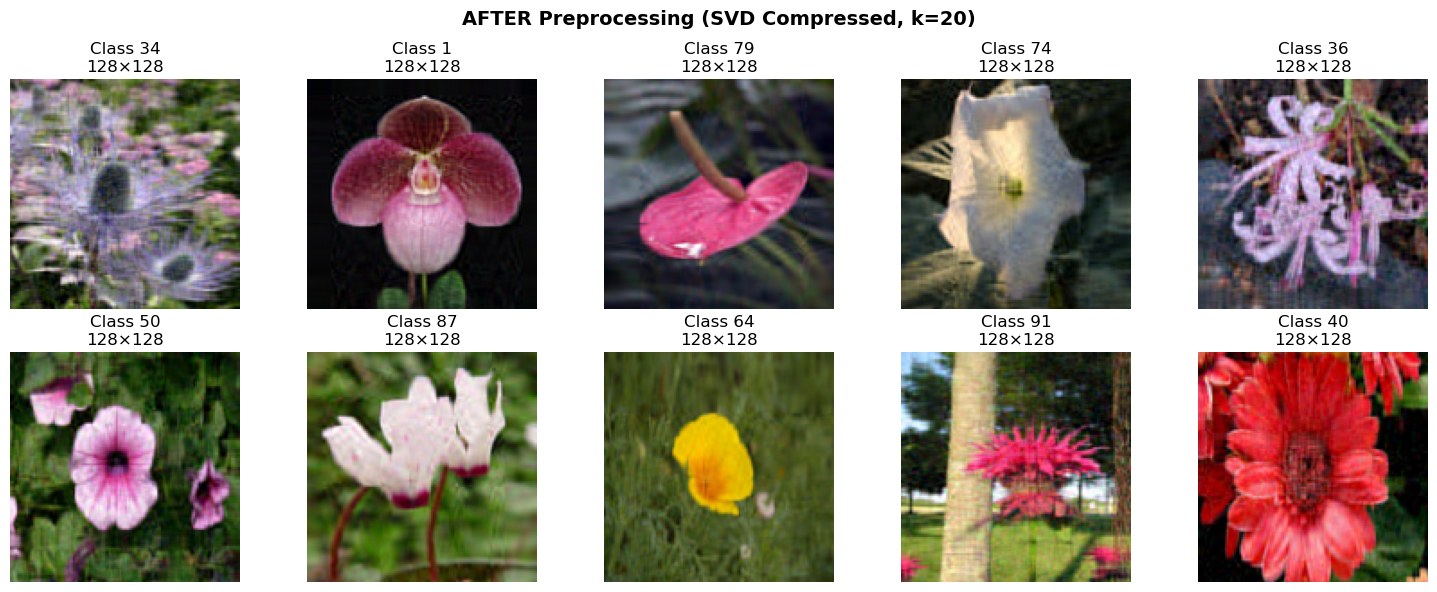

Processed image properties:
  - Standardized size: 128×128
  - SVD compressed: A = U_k × Σ_k × V_T_k
  - Features per image: 15,420
  - Original pixels: 49,152
  - Compression ratio: 3.19×


In [7]:
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
axes = axes.flatten()

# Use same random indices for comparison
for idx, ax in enumerate(axes):
    img_idx = random_indices[idx]
    
    # CHANGE: Reconstruct image from SVD components (can't just reshape!)
    img = reconstruct_from_features(X_train_svd[img_idx], k, IMAGE_SIZE)
    
    # Normalize to 0-1 for display
    img = (img - img.min()) / (img.max() - img.min())
    ax.imshow(img)
    ax.set_title(f"Class {y_train[img_idx]}\n{IMAGE_SIZE[0]}×{IMAGE_SIZE[1]}")
    ax.axis('off')

plt.suptitle(f"AFTER Preprocessing (SVD Compressed, k={k})", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"Processed image properties:")
print(f"  - Standardized size: {IMAGE_SIZE[0]}×{IMAGE_SIZE[1]}")
print(f"  - SVD compressed: A = U_k × Σ_k × V_T_k")
print(f"  - Features per image: {X_train_svd.shape[1]:,}")  # CHANGE: Actual feature count
print(f"  - Original pixels: {IMAGE_SIZE[0] * IMAGE_SIZE[1] * 3:,}")
print(f"  - Compression ratio: {(IMAGE_SIZE[0] * IMAGE_SIZE[1] * 3) / X_train_svd.shape[1]:.2f}×")

In [8]:
print("="*70)
print("DATA PREPROCESSING COMPLETE - READY FOR TRAINING")
print("="*70)

print("\n📊 Dataset Shapes:")
print(f"  X_train: {X_train_svd.shape}")
print(f"  y_train: {y_train.shape}")
print(f"  X_valid: {X_valid_svd.shape}")
print(f"  y_valid: {y_valid.shape}")
print(f"  X_test:  {X_test_svd.shape}")

print("\n✅ Configuration:")
print(f"  Image size: {IMAGE_SIZE}")
print(f"  k value: {k}")
print(f"  Features per image: {X_train_svd.shape[1]:,}")
print(f"  Number of classes: {len(np.unique(y_train))}")

print("\n📈 Data Statistics:")
print(f"  Training samples: {len(X_train_svd):,}")
print(f"  Validation samples: {len(X_valid_svd):,}")
print(f"  Test samples: {len(X_test_svd):,}")

print("\n🎯 Quality Check:")
# Test reconstruction on one random image
test_idx = np.random.randint(0, len(X_train_svd))
reconstructed = reconstruct_from_features(X_train_svd[test_idx], k, IMAGE_SIZE)
print(f"  ✓ Reconstruction works: {reconstructed.shape}")
print(f"  ✓ Min pixel value: {reconstructed.min():.2f}")
print(f"  ✓ Max pixel value: {reconstructed.max():.2f}")

print("\n" + "="*70)
print("✨ PREPROCESSING COMPLETE! READY TO TRAIN MODELS!")
print("="*70)

DATA PREPROCESSING COMPLETE - READY FOR TRAINING

📊 Dataset Shapes:
  X_train: (6552, 15420)
  y_train: (6552,)
  X_valid: (818, 15420)
  y_valid: (818,)
  X_test:  (819, 15420)

✅ Configuration:
  Image size: (128, 128)
  k value: 20
  Features per image: 15,420
  Number of classes: 102

📈 Data Statistics:
  Training samples: 6,552
  Validation samples: 818
  Test samples: 819

🎯 Quality Check:
  ✓ Reconstruction works: (128, 128, 3)
  ✓ Min pixel value: 0.00
  ✓ Max pixel value: 214.73

✨ PREPROCESSING COMPLETE! READY TO TRAIN MODELS!


## END TESTING

---

# Model 2: Artificial Neural Network

In [ ]:
# ==============================================================================
# MODEL 2: ARTIFICIAL NEURAL NETWORK (ANN)
# ==============================================================================
# 
# PIPELINE OVERVIEW:
# 1. Standardize features (mean=0, std=1)
# 2. Apply PCA for dimensionality reduction
# 3. Create PyTorch DataLoaders
# 4. Define ANN architecture
# 5. Train with early stopping
# 6. Hyperparameter search (optional)
# 7. Multi-seed evaluation for robustness
# ==============================================================================

In [31]:

# STEP 1: DATA PREPROCESSING
print("=" * 70)
print("ANN PREPROCESSING: STANDARDIZATION + PCA")
print("=" * 70)

# 1.1) Standardization (Critical for ANN performance)
# Why: Neural networks learn best when all features have similar scales
# Method: Transform each feature to have mean=0 and standard deviation=1

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_svd)  # Fit on training data only
X_valid_scaled = scaler.transform(X_valid_svd)      # Transform validation
X_test_scaled  = scaler.transform(X_test_svd)       # Transform test

print(f"✓ Scaled shapes: Train={X_train_scaled.shape}, Valid={X_valid_scaled.shape}")

# 1.2) PCA Dimensionality Reduction
# Why: Reduces features to 256, making training faster
# Trade-off: Loses some information but reduces overfitting

# Start with 256 components (can tune this in hyperparameter search)
pca = PCA(n_components=256, random_state=42)
X_train_pca = pca.fit_transform(X_train_scaled)
X_valid_pca = pca.transform(X_valid_scaled)
X_test_pca  = pca.transform(X_test_scaled)

variance_retained = pca.explained_variance_ratio_.sum() * 100

print(f"✓ PCA complete:")
print(f"  Train: {X_train_pca.shape}")
print(f"  Valid: {X_valid_pca.shape}")
print(f"  Test:  {X_test_pca.shape}")
print(f"  Variance retained: {variance_retained:.2f}%")


# 1.3) Create PyTorch DataLoaders
# Why: DataLoaders efficiently batch data and shuffle during training

# Convert to PyTorch tensors
X_train_t = torch.tensor(X_train_pca, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.long)

X_valid_t = torch.tensor(X_valid_pca, dtype=torch.float32)
y_valid_t = torch.tensor(y_valid, dtype=torch.long)

X_test_t = torch.tensor(X_test_pca, dtype=torch.float32)

# Create DataLoaders
batch_size = 64
train_loader = DataLoader(
    TensorDataset(X_train_t, y_train_t),
    batch_size=batch_size,
    shuffle=True  # Shuffle training data each epoch
)

valid_loader = DataLoader(
    TensorDataset(X_valid_t, y_valid_t),
    batch_size=batch_size,
    shuffle=False  # Don't shuffle validation
)

print(f"✓ DataLoaders created:")
print(f"  Batch size: {batch_size}")
print(f"  Train batches: {len(train_loader)}")
print(f"  Valid batches: {len(valid_loader)}")

ANN PREPROCESSING: STANDARDIZATION + PCA
✓ Scaled shapes: Train=(6552, 15420), Valid=(818, 15420)
✓ PCA complete:
  Train: (6552, 256)
  Valid: (818, 256)
  Test:  (819, 256)
  Variance retained: 27.60%
✓ DataLoaders created:
  Batch size: 64
  Train batches: 103
  Valid batches: 13


In [33]:
# STEP 2: DEFINE ANN ARCHITECTURE
class SimpleANN(nn.Module):
    """
    Simple Artificial Neural Network for flower classification.
    
    Architecture:
        Input (PCA features) → Hidden1 → ReLU → Dropout → 
        Hidden2 → ReLU → Dropout → Output (102 classes)
    
    Args:
        input_dim: Number of input features (PCA components)
        hidden1: Number of neurons in first hidden layer
        hidden2: Number of neurons in second hidden layer
        dropout: Dropout probability (0.0-1.0) for regularization
        num_classes: Number of output classes (102 flower species)
    """
    def __init__(self, input_dim, hidden1=256, hidden2=256, dropout=0.5, num_classes=102):
        super().__init__()
        self.net = nn.Sequential(
            # First hidden layer
            nn.Linear(input_dim, hidden1),
            nn.ReLU(),                      # Non-linear activation
            nn.Dropout(dropout),            # Regularization
            
            # Second hidden layer
            nn.Linear(hidden1, hidden2),
            nn.ReLU(),
            nn.Dropout(dropout),
            
            # Output layer (no activation - handled by CrossEntropyLoss)
            nn.Linear(hidden2, num_classes),
        )
    
    def forward(self, x):
        return self.net(x)

# Device configuration
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Initialize model with default hyperparameters
model = SimpleANN(
    input_dim=X_train_pca.shape[1],  # 256 PCA components
    hidden1=256,
    hidden2=256,
    dropout=0.5,
    num_classes=102
).to(device)

# Count parameters
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"\nModel Architecture:")
print(model)
print(f"\nTotal parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")

Using device: cpu

Model Architecture:
SimpleANN(
  (net): Sequential(
    (0): Linear(in_features=256, out_features=256, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.5, inplace=False)
    (3): Linear(in_features=256, out_features=256, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.5, inplace=False)
    (6): Linear(in_features=256, out_features=102, bias=True)
  )
)

Total parameters: 157,798
Trainable parameters: 157,798


In [34]:
# STEP 3: INITIAL TRAINING (BASELINE)

print("TRAINING BASELINE MODEL")

# Loss function and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=5e-4,              # Learning rate
    weight_decay=1e-3     # L2 regularization
)

# Training configuration
NUM_EPOCHS = 30
PATIENCE = 5  # Early stopping patience

# Helper function
def accuracy_from_logits(logits, y):
    """Calculate accuracy from model outputs."""
    preds = torch.argmax(logits, dim=1)
    return (preds == y).float().mean().item()

# Training loop
best_val_acc = 0.0
wait = 0
history = {'train_loss': [], 'train_acc': [], 'val_acc': []}

print(f"\nTraining for up to {NUM_EPOCHS} epochs (early stopping patience={PATIENCE})\n")

for epoch in range(1, NUM_EPOCHS + 1):
    # -------------------------------------------------------------------------
    # Training phase
    # -------------------------------------------------------------------------
    model.train()
    train_loss = 0.0
    train_acc = 0.0
    
    for Xb, yb in train_loader:
        Xb, yb = Xb.to(device), yb.to(device)
        
        # Forward pass
        optimizer.zero_grad()
        logits = model(Xb)
        loss = criterion(logits, yb)
        
        # Backward pass
        loss.backward()
        optimizer.step()
        
        # Track metrics
        train_loss += loss.item()
        train_acc += accuracy_from_logits(logits, yb)
    
    train_loss /= len(train_loader)
    train_acc /= len(train_loader)
    
    # -------------------------------------------------------------------------
    # Validation phase
    # -------------------------------------------------------------------------
    model.eval()
    val_acc = 0.0
    
    with torch.no_grad():
        for Xb, yb in valid_loader:
            Xb, yb = Xb.to(device), yb.to(device)
            logits = model(Xb)
            val_acc += accuracy_from_logits(logits, yb)
    
    val_acc /= len(valid_loader)
    
    # Store history
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_acc'].append(val_acc)
    
    # Print progress
    print(f"Epoch {epoch:02d}/{NUM_EPOCHS} | "
          f"Loss: {train_loss:.4f} | "
          f"Train Acc: {train_acc*100:.2f}% | "
          f"Val Acc: {val_acc*100:.2f}%")
    
    # -------------------------------------------------------------------------
    # Early stopping check
    # -------------------------------------------------------------------------
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        wait = 0
        torch.save(model.state_dict(), "best_ann_baseline.pth")
        print(f"  → New best! Saved model.")
    else:
        wait += 1
        if wait >= PATIENCE:
            print(f"\nEarly stopping triggered. Best Val Acc: {best_val_acc*100:.2f}%")
            break

print("\n" + "=" * 70)
print(f"BASELINE TRAINING COMPLETE")
print(f"Best Validation Accuracy: {best_val_acc*100:.2f}%")
print("=" * 70)

TRAINING BASELINE MODEL

Training for up to 30 epochs (early stopping patience=5)

Epoch 01/30 | Loss: 4.6455 | Train Acc: 2.43% | Val Acc: 2.88%
  → New best! Saved model.
Epoch 02/30 | Loss: 4.4406 | Train Acc: 5.04% | Val Acc: 6.61%
  → New best! Saved model.
Epoch 03/30 | Loss: 4.2527 | Train Acc: 6.32% | Val Acc: 9.74%
  → New best! Saved model.
Epoch 04/30 | Loss: 4.0324 | Train Acc: 8.37% | Val Acc: 11.66%
  → New best! Saved model.
Epoch 05/30 | Loss: 3.8318 | Train Acc: 10.36% | Val Acc: 12.62%
  → New best! Saved model.
Epoch 06/30 | Loss: 3.6903 | Train Acc: 11.81% | Val Acc: 12.26%
Epoch 07/30 | Loss: 3.5320 | Train Acc: 14.90% | Val Acc: 14.61%
  → New best! Saved model.
Epoch 08/30 | Loss: 3.4185 | Train Acc: 16.71% | Val Acc: 14.10%
Epoch 09/30 | Loss: 3.3316 | Train Acc: 18.07% | Val Acc: 15.57%
  → New best! Saved model.
Epoch 10/30 | Loss: 3.2388 | Train Acc: 19.85% | Val Acc: 15.97%
  → New best! Saved model.
Epoch 11/30 | Loss: 3.1469 | Train Acc: 20.96% | Val Acc: 

In [35]:
# STEP 4: HYPERPARAMETER SEARCH

print("HYPERPARAMETER SEARCH")

# Set constants
NUM_CLASSES = 102
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# -----------------------------------------------------------------------------
# Helper Functions
# -----------------------------------------------------------------------------

def set_seed(seed=42):
    """Set random seeds for reproducibility."""
    import random
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

def evaluate(model, loader):
    """Evaluate model on a dataloader."""
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            preds = model(xb).argmax(dim=1)
            correct += (preds == yb).sum().item()
            total += yb.size(0)
    return correct / max(total, 1)

def train_and_validate(X_train, y_train, X_valid, y_valid,
                       config, num_classes=102, epochs=30, 
                       batch_size=64, patience=5, seed=42, verbose=False):
    """
    Train model with given configuration.
    
    Returns:
        best_val_acc: Best validation accuracy achieved
        best_state: Model state dict at best validation
    """
    set_seed(seed)
    
    # Create dataloaders
    Xtr = torch.tensor(X_train, dtype=torch.float32)
    ytr = torch.tensor(y_train, dtype=torch.long)
    Xva = torch.tensor(X_valid, dtype=torch.float32)
    yva = torch.tensor(y_valid, dtype=torch.long)
    
    train_loader = DataLoader(TensorDataset(Xtr, ytr), 
                              batch_size=batch_size, shuffle=True)
    valid_loader = DataLoader(TensorDataset(Xva, yva), 
                              batch_size=batch_size, shuffle=False)
    
    # Create model
    model = SimpleANN(
        input_dim=X_train.shape[1],
        hidden1=config["hidden1"],
        hidden2=config["hidden2"],
        dropout=config["dropout"],
        num_classes=num_classes
    ).to(device)
    
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=config["lr"],
        weight_decay=config["weight_decay"]
    )
    
    best_val = -1.0
    best_state = None
    wait = 0
    
    for epoch in range(1, epochs + 1):
        # Train
        model.train()
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            logits = model(xb)
            loss = criterion(logits, yb)
            loss.backward()
            optimizer.step()
        
        # Validate
        val_acc = evaluate(model, valid_loader)
        
        if verbose:
            print(f"  Epoch {epoch:02d}/{epochs} | Val {val_acc*100:.2f}%")
        
        # Early stopping
        if val_acc > best_val + 1e-6:
            best_val = val_acc
            best_state = deepcopy(model.state_dict())
            wait = 0
        else:
            wait += 1
            if wait >= patience:
                break
    
    return best_val, best_state

def apply_pca(X_train_scaled, X_valid_scaled, pca_dim, seed=42):
    """Apply PCA transformation."""
    pca = PCA(n_components=pca_dim, random_state=seed)
    X_train_pca = pca.fit_transform(X_train_scaled)
    X_valid_pca = pca.transform(X_valid_scaled)
    var_retained = float(pca.explained_variance_ratio_.sum())
    return X_train_pca, X_valid_pca, var_retained, pca

# -----------------------------------------------------------------------------
# Define Search Space
# -----------------------------------------------------------------------------

search_space = {
    "pca_dim":      [256, 512, 1024],
    "hidden1":      [256, 512, 768],
    "hidden2":      [128, 256],
    "dropout":      [0.3, 0.4, 0.5],
    "lr":           [1e-3, 5e-4, 3e-4],
    "weight_decay": [1e-4, 1e-3, 5e-3],
}

# Generate all combinations
MAX_TRIALS = 50  # Limit for computational efficiency
all_configs = list(product(
    search_space["pca_dim"],
    search_space["hidden1"],
    search_space["hidden2"],
    search_space["dropout"],
    search_space["lr"],
    search_space["weight_decay"],
))

# Shuffle and limit (random search)
rng = np.random.default_rng(42)
rng.shuffle(all_configs)
all_configs = all_configs[:MAX_TRIALS]

print(f"\nSearching {len(all_configs)} hyperparameter configurations...")
print(f"This will take approximately {len(all_configs) * 2} minutes.\n")

# -----------------------------------------------------------------------------
# Run Search
# -----------------------------------------------------------------------------

best_overall = {
    "val_acc": -1.0,
    "config": None,
    "state_dict": None,
    "pca": None,
    "variance_retained": None
}

for idx, (pca_dim, h1, h2, dr, lr, wd) in enumerate(all_configs, start=1):
    # Apply PCA with current dimension
    Xtr_pca, Xva_pca, var_ret, pca_obj = apply_pca(
        X_train_scaled, X_valid_scaled, pca_dim, seed=42
    )
    
    config = {
        "pca_dim": pca_dim,
        "hidden1": h1,
        "hidden2": h2,
        "dropout": dr,
        "lr": lr,
        "weight_decay": wd
    }
    
    # Train and validate
    val_acc, state = train_and_validate(
        Xtr_pca, y_train,
        Xva_pca, y_valid,
        config=config,
        num_classes=NUM_CLASSES,
        epochs=30,
        batch_size=64,
        patience=5,
        seed=42,
        verbose=False
    )
    
    print(f"[{idx:02d}/{MAX_TRIALS}] PCA={pca_dim} (var={var_ret*100:.1f}%) | "
          f"h1={h1} h2={h2} dr={dr:.1f} lr={lr:.4f} wd={wd:.4f} "
          f"→ Val={val_acc*100:.2f}%")
    
    # Update best
    if val_acc > best_overall["val_acc"]:
        best_overall.update({
            "val_acc": val_acc,
            "config": config,
            "state_dict": state,
            "pca": pca_obj,
            "variance_retained": var_ret
        })
        print(f"  🌟 NEW BEST!")

# -----------------------------------------------------------------------------
# Results
# -----------------------------------------------------------------------------

print("\n" + "=" * 70)
print("HYPERPARAMETER SEARCH COMPLETE")
print("=" * 70)
print(f"\nBest Validation Accuracy: {best_overall['val_acc']*100:.2f}%")
print(f"Variance Retained (PCA): {best_overall['variance_retained']*100:.2f}%")
print(f"\nBest Configuration:")
for key, value in best_overall["config"].items():
    print(f"  {key:15s}: {value}")

# -----------------------------------------------------------------------------
# Save Best Model
# -----------------------------------------------------------------------------

import joblib

torch.save(best_overall["state_dict"], "best_ann_hypersearch.pth")
joblib.dump(scaler, "scaler.joblib")
joblib.dump(best_overall["pca"], "pca_best.joblib")

print(f"\n✓ Saved: best_ann_hypersearch.pth, scaler.joblib, pca_best.joblib")
print("=" * 70)

HYPERPARAMETER SEARCH

Searching 50 hyperparameter configurations...
This will take approximately 100 minutes.

[01/50] PCA=512 (var=41.5%) | h1=256 h2=256 dr=0.4 lr=0.0003 wd=0.0001 → Val=15.04%
  🌟 NEW BEST!
[02/50] PCA=512 (var=41.5%) | h1=256 h2=256 dr=0.5 lr=0.0003 wd=0.0001 → Val=15.40%
  🌟 NEW BEST!
[03/50] PCA=512 (var=41.5%) | h1=256 h2=128 dr=0.4 lr=0.0005 wd=0.0050 → Val=13.81%
[04/50] PCA=512 (var=41.5%) | h1=768 h2=256 dr=0.3 lr=0.0003 wd=0.0050 → Val=13.33%
[05/50] PCA=256 (var=27.6%) | h1=768 h2=256 dr=0.3 lr=0.0010 wd=0.0001 → Val=15.04%
[06/50] PCA=256 (var=27.6%) | h1=256 h2=256 dr=0.4 lr=0.0005 wd=0.0010 → Val=17.60%
  🌟 NEW BEST!
[07/50] PCA=512 (var=41.5%) | h1=512 h2=128 dr=0.3 lr=0.0010 wd=0.0010 → Val=13.57%
[08/50] PCA=512 (var=41.5%) | h1=768 h2=256 dr=0.4 lr=0.0005 wd=0.0010 → Val=14.06%
[09/50] PCA=1024 (var=60.5%) | h1=256 h2=256 dr=0.3 lr=0.0003 wd=0.0010 → Val=14.30%
[10/50] PCA=512 (var=41.5%) | h1=512 h2=256 dr=0.5 lr=0.0010 wd=0.0010 → Val=14.30%
[11/5

In [36]:
# ==============================================================================
# STEP 5: MULTI-SEED ROBUSTNESS TEST
# ==============================================================================

print("=" * 70)
print("TESTING ROBUSTNESS ACROSS MULTIPLE SEEDS")
print("=" * 70)

# Load best hyperparameters from search
best_config = best_overall["config"]

# Load best PCA
pca_best = joblib.load("pca_best.joblib")
X_train_pca_best = pca_best.transform(X_train_scaled)
X_valid_pca_best = pca_best.transform(X_valid_scaled)

print(f"\nUsing best hyperparameters:")
for key, value in best_config.items():
    print(f"  {key:15s}: {value}")

# Test multiple seeds
test_seeds = [1, 13, 24, 42, 50, 69, 73, 88, 96, 123, 999]

print(f"\nTraining with {len(test_seeds)} different random seeds...")
print("This tests how sensitive the model is to initialization.\n")

results = []

for seed in test_seeds:
    val_acc, model_state = train_and_validate(
        X_train_pca_best, y_train,
        X_valid_pca_best, y_valid,
        config=best_config,
        num_classes=NUM_CLASSES,
        epochs=30,
        batch_size=64,
        patience=5,
        seed=seed,
        verbose=False
    )
    
    results.append({
        'seed': seed,
        'val_acc': val_acc
    })
    
    print(f"Seed {seed:3d}: Val Acc = {val_acc*100:.2f}%")

# Summary statistics
val_accs = [r['val_acc'] for r in results]
mean_acc = np.mean(val_accs)
std_acc = np.std(val_accs)
best_seed = results[np.argmax(val_accs)]['seed']
best_seed_acc = max(val_accs)

print("\n" + "=" * 70)
print("MULTI-SEED RESULTS")
print("=" * 70)
print(f"Mean Validation Accuracy: {mean_acc*100:.2f}%")
print(f"Std Deviation:            {std_acc*100:.2f}%")
print(f"Best Seed:                {best_seed} ({best_seed_acc*100:.2f}%)")
print(f"Worst Seed:               {results[np.argmin(val_accs)]['seed']} ({min(val_accs)*100:.2f}%)")
print("=" * 70)

# Visualize distribution
import pandas as pd

df_results = pd.DataFrame(results)
df_results = df_results.sort_values('val_acc', ascending=False)
print("\nFull Results (sorted by accuracy):")
print(df_results.to_string(index=False))

TESTING ROBUSTNESS ACROSS MULTIPLE SEEDS

Using best hyperparameters:
  pca_dim        : 256
  hidden1        : 256
  hidden2        : 256
  dropout        : 0.5
  lr             : 0.001
  weight_decay   : 0.0001

Training with 11 different random seeds...
This tests how sensitive the model is to initialization.

Seed   1: Val Acc = 15.77%
Seed  13: Val Acc = 16.87%
Seed  24: Val Acc = 16.87%
Seed  42: Val Acc = 17.73%
Seed  50: Val Acc = 17.24%
Seed  69: Val Acc = 16.14%
Seed  73: Val Acc = 18.09%
Seed  88: Val Acc = 18.46%
Seed  96: Val Acc = 16.38%
Seed 123: Val Acc = 16.99%
Seed 999: Val Acc = 16.87%

MULTI-SEED RESULTS
Mean Validation Accuracy: 17.04%
Std Deviation:            0.77%
Best Seed:                88 (18.46%)
Worst Seed:               1 (15.77%)

Full Results (sorted by accuracy):
 seed  val_acc
   88 0.184597
   73 0.180929
   42 0.177262
   50 0.172372
  123 0.169927
   13 0.168704
   24 0.168704
  999 0.168704
   96 0.163814
   69 0.161369
    1 0.157702


In [37]:
# ==============================================================================
# STEP 6: FINAL MODEL SELECTION
# ==============================================================================

print("=" * 70)
print("FINAL MODEL SELECTION")
print("=" * 70)

# Decision: Use best seed with best hyperparameters
FINAL_SEED = best_seed  # From multi-seed test

print(f"\nTraining final model with:")
print(f"  - Best hyperparameters from grid search")
print(f"  - Best seed from robustness test: {FINAL_SEED}")
print(f"\nThis combines both optimization strategies.\n")

# Train final model
final_val_acc, final_state = train_and_validate(
    X_train_pca_best, y_train,
    X_valid_pca_best, y_valid,
    config=best_config,
    num_classes=NUM_CLASSES,
    epochs=30,
    batch_size=64,
    patience=5,
    seed=FINAL_SEED,
    verbose=True  # Show epoch-by-epoch progress
)

# Save final model
torch.save(final_state, "best_ann_final.pth")

print("\n" + "=" * 70)
print("FINAL MODEL TRAINING COMPLETE")
print("=" * 70)
print(f"Final Validation Accuracy: {final_val_acc*100:.2f}%")
print(f"Improvement over baseline: {(final_val_acc - best_val_acc)*100:.2f}%")
print(f"\n✓ Saved: best_ann_final.pth")
print("=" * 70)

FINAL MODEL SELECTION

Training final model with:
  - Best hyperparameters from grid search
  - Best seed from robustness test: 88

This combines both optimization strategies.

  Epoch 01/30 | Val 6.72%
  Epoch 02/30 | Val 8.19%
  Epoch 03/30 | Val 11.61%
  Epoch 04/30 | Val 12.22%
  Epoch 05/30 | Val 14.79%
  Epoch 06/30 | Val 16.87%
  Epoch 07/30 | Val 15.77%
  Epoch 08/30 | Val 17.48%
  Epoch 09/30 | Val 17.11%
  Epoch 10/30 | Val 18.46%
  Epoch 11/30 | Val 17.36%
  Epoch 12/30 | Val 16.26%
  Epoch 13/30 | Val 16.50%
  Epoch 14/30 | Val 15.53%
  Epoch 15/30 | Val 16.50%

FINAL MODEL TRAINING COMPLETE
Final Validation Accuracy: 18.46%
Improvement over baseline: 2.37%

✓ Saved: best_ann_final.pth


---

# Model 3: Convolutional Neural Network

In [14]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader
from torch import optim
from tqdm import tqdm

In [35]:
def prepare_for_cnn(X_svd, y):
    """ OLD:
    Reshape flattened SVD images to CNN format (N, C, H, W).
    # Reshape from (N, k*k*3) to (N, k, k, 3)
    X_reshaped = X.reshape(-1, IMAGE_SIZE[0], IMAGE_SIZE[1], 3)
    # Convert to (N, 3, k, k) - PyTorch expects channels first
    X_reshaped = np.transpose(X_reshaped, (0, 3, 1, 2))
    # Normalize to [0, 1]
    X_reshaped = (X_reshaped - X_reshaped.min()) / (X_reshaped.max() - X_reshaped.min())
    # Convert to tensors
    X_tensor = torch.FloatTensor(X_reshaped)
    y_tensor = torch.LongTensor(y)
    return X_tensor, y_tensor """

    # NEW: Reconstruct images from SVD components, then prepare for CNN
    print(f"🔄 Reconstructing {len(X_svd)} images from SVD features...")
    
    # Step 1: Reconstruct all images from SVD components
    X_reconstructed = []
    for i in range(len(X_svd)):
        img = reconstruct_from_features(X_svd[i], k, IMAGE_SIZE)
        X_reconstructed.append(img)
        
        # Progress indicator
        if (i + 1) % 1000 == 0:
            print(f"  Reconstructed {i+1}/{len(X_svd)} images...")
    
    X_reconstructed = np.array(X_reconstructed)  # Shape: (N, 128, 128, 3)
    print(f"✓ Reconstruction complete: {X_reconstructed.shape}")
    
    # Step 2: Convert to (N, 3, H, W) - PyTorch format (channels first)
    X_reshaped = np.transpose(X_reconstructed, (0, 3, 1, 2))
    
    # Step 3: Normalize to [0, 1]
    X_reshaped = X_reshaped / 255.0  # Images are 0-255, normalize to 0-1
    
    # Step 4: Convert to tensors
    X_tensor = torch.FloatTensor(X_reshaped)
    y_tensor = torch.LongTensor(y)
    
    return X_tensor, y_tensor


# Prepare data (this will take a few minutes)
print("="*70)
print("PREPARING DATA FOR CNN")
print("="*70)

# For test set, create dummy labels (they won't be used for evaluation anyway)
y_test = np.zeros(len(X_test_svd), dtype=int)  # All zeros (placeholder)

X_train_tensor, y_train_tensor = prepare_for_cnn(X_train_svd, y_train)
X_valid_tensor, y_valid_tensor = prepare_for_cnn(X_valid_svd, y_valid)
X_test_tensor, y_test_tensor = prepare_for_cnn(X_test_svd, y_test)

print(f"\n✓ All data prepared!")
print(f"  X_train_tensor: {X_train_tensor.shape}")  # (6552, 3, 128, 128)
print(f"  X_valid_tensor: {X_valid_tensor.shape}")  # (818, 3, 128, 128)
print(f"  X_test_tensor:  {X_test_tensor.shape}")   # (819, 3, 128, 128)

# Create DataLoaders
batch_size = 32

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
valid_dataset = TensorDataset(X_valid_tensor, y_valid_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
valid_loader = DataLoader(valid_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print(f"\n✓ DataLoaders created:")
print(f"  Train batches: {len(train_loader)}")
print(f"  Valid batches: {len(valid_loader)}")
print(f"  Test batches: {len(test_loader)}")
print("="*70)

PREPARING DATA FOR CNN
🔄 Reconstructing 6552 images from SVD features...
  Reconstructed 1000/6552 images...
  Reconstructed 2000/6552 images...
  Reconstructed 3000/6552 images...
  Reconstructed 4000/6552 images...
  Reconstructed 5000/6552 images...
  Reconstructed 6000/6552 images...
✓ Reconstruction complete: (6552, 128, 128, 3)
🔄 Reconstructing 818 images from SVD features...
✓ Reconstruction complete: (818, 128, 128, 3)
🔄 Reconstructing 819 images from SVD features...
✓ Reconstruction complete: (819, 128, 128, 3)

✓ All data prepared!
  X_train_tensor: torch.Size([6552, 3, 128, 128])
  X_valid_tensor: torch.Size([818, 3, 128, 128])
  X_test_tensor:  torch.Size([819, 3, 128, 128])

✓ DataLoaders created:
  Train batches: 205
  Valid batches: 26
  Test batches: 26


In [44]:
class CNN(nn.Module):
    def __init__(self, input_size, in_channels=3, num_classes=102):
        super(CNN, self).__init__()
        
        # Conv blocks with Batch Normalization
        self.conv1 = nn.Conv2d(in_channels, 32, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(32)
        
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(64)
        
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm2d(128)
        
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        self.dropout_conv = nn.Dropout2d(0.25)  # Dropout for conv layers
        
        # Calculate FC size
        fc_size = input_size // 8
        
        self.fc1 = nn.Linear(128 * fc_size * fc_size, 512)
        self.bn_fc = nn.BatchNorm1d(512)
        self.dropout = nn.Dropout(0.5)
        self.fc2 = nn.Linear(512, num_classes)

    def forward(self, x):
        x = self.pool(F.relu(self.bn1(self.conv1(x))))
        x = self.dropout_conv(x)
        
        x = self.pool(F.relu(self.bn2(self.conv2(x))))
        x = self.dropout_conv(x)
        
        x = self.pool(F.relu(self.bn3(self.conv3(x))))
        x = self.dropout_conv(x)
        
        x = x.reshape(x.shape[0], -1)
        x = self.dropout(F.relu(self.bn_fc(self.fc1(x))))
        x = self.fc2(x)
        return x

In [46]:
device = "cuda" if torch.cuda.is_available() else "cpu"
model = CNN(input_size=IMAGE_SIZE[0], in_channels=3, num_classes=102).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)

# Learning rate scheduler - reduces LR when validation loss plateaus
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', patience=3, factor=0.5)

num_epochs = 30  # More epochs since we have early stopping

In [47]:

best_val_acc = 0
patience = 5
patience_counter = 0

for epoch in range(num_epochs):
    # Training
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    
    for data, targets in tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs}"):
        data = data.to(device)
        targets = targets.to(device)
        
        optimizer.zero_grad()
        outputs = model(data)
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
        _, predicted = outputs.max(1)
        total += targets.size(0)
        correct += predicted.eq(targets).sum().item()
    
    train_acc = 100. * correct / total
    avg_loss = running_loss / len(train_loader)
    
    # Validation
    model.eval()
    val_correct = 0
    val_total = 0
    with torch.no_grad():
        for data, targets in valid_loader:
            data = data.to(device)
            targets = targets.to(device)
            outputs = model(data)
            _, predicted = outputs.max(1)
            val_total += targets.size(0)
            val_correct += predicted.eq(targets).sum().item()
    
    val_acc = 100. * val_correct / val_total
    
    # Step scheduler based on validation accuracy
    old_lr = optimizer.param_groups[0]['lr']
    scheduler.step(val_acc)
    new_lr = optimizer.param_groups[0]['lr']
    if new_lr != old_lr:
        print(f"  ↓ Learning rate reduced: {old_lr} → {new_lr}")
    
    print(f"  Loss: {avg_loss:.4f} | Train Acc: {train_acc:.2f}% | Val Acc: {val_acc:.2f}%")
    
    # Early stopping check
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        patience_counter = 0
        # Save best model
        torch.save(model.state_dict(), 'best_model.pth')
        print(f"  ✓ New best model saved! (Val Acc: {val_acc:.2f}%)")
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print(f"\n⚠️ Early stopping at epoch {epoch+1} (no improvement for {patience} epochs)")
            break

print(f"\nBest Validation Accuracy: {best_val_acc:.2f}%")

# Load best model for evaluation
model.load_state_dict(torch.load('best_model.pth'))

Epoch 1/30: 100%|██████████| 205/205 [01:32<00:00,  2.21it/s]


  Loss: 3.8965 | Train Acc: 11.46% | Val Acc: 23.96%
  ✓ New best model saved! (Val Acc: 23.96%)


Epoch 2/30: 100%|██████████| 205/205 [01:32<00:00,  2.22it/s]


  Loss: 3.1559 | Train Acc: 22.16% | Val Acc: 32.64%
  ✓ New best model saved! (Val Acc: 32.64%)


Epoch 3/30: 100%|██████████| 205/205 [01:32<00:00,  2.22it/s]


...

Epoch 23/30: 100%|██████████| 205/205 [01:33<00:00,  2.20it/s]


  ↓ Learning rate reduced: 0.0005 → 0.00025
  Loss: 0.1671 | Train Acc: 95.94% | Val Acc: 52.81%


Epoch 24/30: 100%|██████████| 205/205 [01:33<00:00,  2.20it/s]


  Loss: 0.1271 | Train Acc: 97.13% | Val Acc: 52.08%

⚠️ Early stopping at epoch 24 (no improvement for 5 epochs)

Best Validation Accuracy: 53.30%


<All keys matched successfully>

In [51]:
from torchmetrics import Accuracy

acc_metric = Accuracy(task="multiclass", num_classes=102).to(device)

model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in tqdm(test_loader, desc="Testing"):
        images = images.to(device)
        labels = labels.to(device)
        
        outputs = model(images)
        _, preds = torch.max(outputs, 1)
        
        acc_metric.update(preds, labels)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

test_accuracy = acc_metric.compute()
print(f"\nTest Accuracy: {test_accuracy*100:.2f}%")
print("\n⚠️ Note: Test labels are placeholders (all zeros).")

Testing: 100%|██████████| 26/26 [00:03<00:00,  7.46it/s]


Test Accuracy: 0.37%

⚠️ Note: Test labels are placeholders (all zeros).
